In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [2]:
train = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/train_sent_emo.csv')
val = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/dev_sent_emo.csv')
test = pd.read_csv('data/raw/MELD-RAW/MELD.Raw/test_sent_emo.csv')

print("train, val(dev), test csv files loaded.")

train, val(dev), test csv files loaded.


In [3]:
print("--- first five samples of train ---")
train.head()

--- first five samples of train ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my company's tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You must've had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So let's talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


In [4]:
print("--- first five samples of val/dev ---")
val.head()

--- first five samples of val/dev ---


,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,"Oh my God, he's lost it. He's totally lost it.",Phoebe,sadness,negative,0,0,4,7,"00:20:57,256","00:21:00,049"
1,2,What?,Monica,surprise,negative,0,1,4,7,"00:21:01,927","00:21:03,261"
2,3,"Or! Or, we could go to the bank, close our acc...",Ross,neutral,neutral,1,0,4,4,"00:12:24,660","00:12:30,915"
3,4,You're a genius!,Chandler,joy,positive,1,1,4,4,"00:12:32,334","00:12:33,960"
4,5,"Aww, man, now we won't be bank buddies!",Joey,sadness,negative,1,2,4,4,"00:12:34,211","00:12:37,505"


In [5]:
shape = pd.DataFrame({
    'train': train.shape,
    'val/dev': val.shape,
    'test': test.shape
})
print("shapes of each dataset:")
shape

shapes of each dataset:


,train,val/dev,test
0,9989,1109,2610
1,11,11,11


In [6]:
print("datatypes of the columns:\n", train.dtypes)

datatypes of the columns:
 Sr No.          int64
Utterance         str
Speaker           str
Emotion           str
Sentiment         str
Dialogue_ID     int64
Utterance_ID    int64
Season          int64
Episode         int64
StartTime         str
EndTime           str
dtype: object


In [49]:
print("number of missing values: ")

missing = pd.Series({
    'train': list(train.isna().sum()),
    'val/dev': list(val.isna().sum()),
    'test': list(test.isna().sum())
})

missing

number of missing values: 


train      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
val/dev    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
test       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dtype: object

In [45]:
print("number of duplicates: ")

duplicates = pd.Series({
    'train': train.duplicated().sum(),
    'val/dev': val.duplicated().sum(),
    'test': test.duplicated().sum()
})

duplicates

number of duplicates: 


train      0
val/dev    0
test       0
dtype: int64

In [7]:
print("number of dialogues in each dataset: ")

dialogues = pd.Series({
    'train': len(train['Dialogue_ID'].unique()),
    'val/dev': len(val['Dialogue_ID'].unique()),
    'test': len(test['Dialogue_ID'].unique()),
})
dialogues

number of dialogues in each dataset: 


train      1038
val/dev     114
test        280
dtype: int64

In [8]:
utterances = pd.Series({
    'train': train.shape[0],
    'val/dev': val.shape[0],
    'test': test.shape[0]
})
print("number of utterances in each dataset:")
utterances

number of utterances in each dataset:


train      9989
val/dev    1109
test       2610
dtype: int64

In [9]:
print("number of unique speakers in train: ", len(train['Speaker'].unique()))
print("unique speakers: ", list(train['Speaker'].unique()))
print()

print("number of unique speakers in val/dev: ", len(val['Speaker'].unique()))
print("unique speakers: ", list(val['Speaker'].unique()))
print()

print("number of unique speakers in test: ", len(test['Speaker'].unique()))
print("unique speakers: ", list(test['Speaker'].unique()))


number of unique speakers in train:  260
unique speakers:  ['Chandler', 'The Interviewer', 'Joey', 'Rachel', 'Monica', 'Phoebe', 'Ross', 'Sergei', 'Customer', 'Jade', 'Mona', 'Charlie', 'Paleontologist', 'Professore Clerk', 'Caitlin', 'Nurse', 'Mr. Treeger', 'Carol', 'The Casting Director', 'Emily', 'Elizabeth', 'Paul', 'The Dry Cleaner', 'Joey and Chandler', 'Kate', 'The Director', 'Mr. Tribbiani', 'Guru Saj', 'Wayne', 'Richard', 'Dina', 'Bobby', 'Danny', 'Krista', 'Jill', 'Doug', 'Stevens', 'Bob', 'Mr. Franklin', 'Director', 'Janice', 'Tony', 'Peter', 'Ticket Counter Attendant', 'Dr. Long', 'Charlton Heston', 'Joshua', 'Nancy', 'Kim', 'Joanna', 'Cassie', 'Dr. Rhodes', 'Dr. Johnson', 'Kristen', 'Jester', 'Sarah', 'Pete', 'The Singing Man', 'Commercial', 'Mark', 'A Female Student', 'All', 'Cliff', 'Tag', 'Eric', 'Dr. Green', 'Mr. Heckles', 'Mr. Geller', 'Sophie', 'Singer', 'David', 'Hitchhiker', '1st Customer', '2nd Customer', '3rd Customer', 'The Presenter', 'Policeman', 'Duncan', 'Ja

In [10]:
train_set = set(train['Speaker'])
val_set = set(val['Speaker'])
test_set = set(test['Speaker'])

all3 = train_set & val_set & test_set
print("number of common speakers in all three datasets: ", len(all3))
print("common speakers in all three datasets: ", all3)
print()

train_val = train_set & val_set
print("number of common speakers in train & val datasets: ", len(train_val))
print("common speakers in train & val datasets: ", train_val)
print()

train_test = train_set & test_set
print("number of common speakers in train & test datasets: ", len(train_test))
print("common speakers in train & test datasets: ", train_test)
print()

val_test = val_set & test_set
print("number of common speakers in val & test datasets: ", len(val_test))
print("common speakers in val & test datasets: ", val_test)

number of common speakers in all three datasets:  21
common speakers in all three datasets:  {'Frank', 'Cliff', 'Phoebe', 'Elizabeth', 'Woman', 'Mrs. Geller', 'Mark', 'Joanna', 'Gary', 'Joey', 'Carol', 'The Dry Cleaner', 'Chandler', 'Bob', 'Tag', 'Guy', 'Rachel', 'Susan', 'Monica', 'Ross', 'All'}

number of common speakers in train & val datasets:  33
common speakers in train & val datasets:  {'Jeannine', 'Cliff', 'Frank', 'Phoebe', 'Elizabeth', 'Woman', 'Ursula', 'Mrs. Geller', 'Mark', 'Joanna', 'Carl', 'Kate', 'Gary', 'Joey', 'Mrs. Green', 'Carol', 'The Dry Cleaner', 'Charlie', 'Kyle', 'Chandler', 'Bob', 'Tag', 'Guy', 'Dr. Long', 'Alice', 'Rachel', 'Doctor', 'Estelle', 'Janine', 'Susan', 'Monica', 'Ross', 'All'}

number of common speakers in train & test datasets:  69
common speakers in train & test datasets:  {'Mr. Geller', 'Dr. Franzblau', 'Janice', 'Cecilia', 'Frank', 'Cliff', 'Phoebe', 'Elizabeth', 'Emily', 'Woman', 'Leslie', 'Dina', 'Mrs. Geller', 'Nancy', 'Sophie', 'Ticket Coun

In [11]:
print("number of utterances per speaker (sorted): ", )

train_utt = dict(Counter(train['Speaker']).most_common())
val_utt = dict(Counter(val['Speaker']).most_common())
test_utt = dict(Counter(test['Speaker']).most_common())
no_utterances = pd.DataFrame({
    'train': train_utt,
    'val': val_utt,
    'test': test_utt
}).fillna(0)

no_utterances.head(10)

number of utterances per speaker (sorted): 


,train,val,test
Joey,1509.0,149.0,411.0
Ross,1459.0,217.0,373.0
Rachel,1435.0,164.0,356.0
Phoebe,1321.0,185.0,291.0
Monica,1299.0,137.0,346.0
Chandler,1283.0,101.0,379.0
Janice,58.0,0.0,31.0
Carol,46.0,13.0,1.0
Emily,43.0,0.0,16.0
Tag,41.0,7.0,12.0


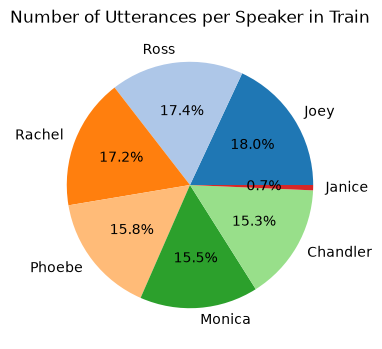

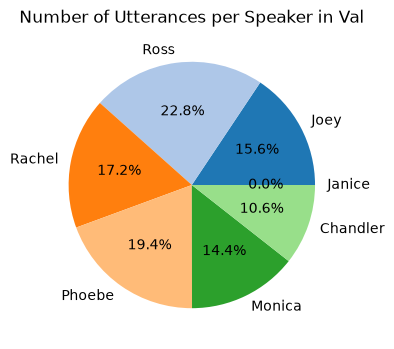

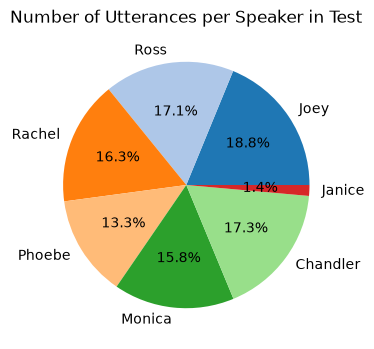

In [12]:
for i in ['train', 'val', 'test']:
    data = no_utterances[i].head(7)
    colors = plt.cm.tab20.colors[: len(no_utterances[i])]
    plt.figure(figsize=(4, 4))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=0,
        colors=colors,
    )

    plt.title(f"Number of Utterances per Speaker in {i.capitalize()}")
    plt.show()


NOTE: Ross has higher samples in the 'val' set than Joey, but is ranked lower as Joey has higher train samples. (internal adjustment by python)

NOTE to self: split == train = phoebe, monica, chandler, janice. val == rachel, ross. test == joey

In [13]:
print("emotion distribution: ")

train_emo = dict(Counter(train['Emotion']).most_common())
val_emo = dict(Counter(val['Emotion']).most_common())
test_emo = dict(Counter(test['Emotion']).most_common())

emo_distb = pd.DataFrame({
    'train': train_emo,
    'val': val_emo,
    'test': test_emo
})

emo_distb

emotion distribution: 


,train,val,test
neutral,4710,470,1256
joy,1743,163,402
surprise,1205,150,281
anger,1109,153,345
sadness,683,111,208
disgust,271,22,68
fear,268,40,50


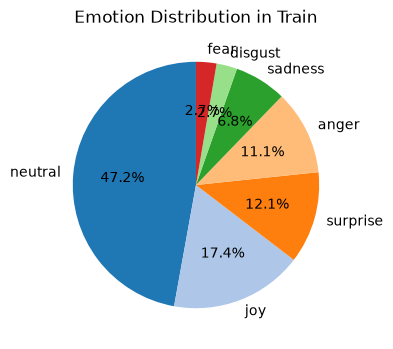

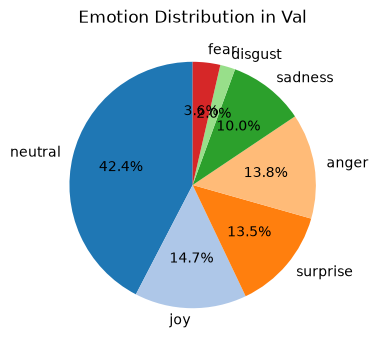

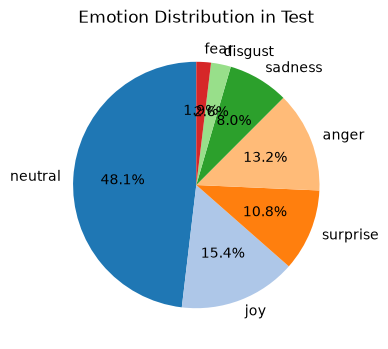

In [14]:
for i in ['train', 'val', 'test']:
    data = emo_distb[i]
    colors = plt.cm.tab20.colors[: len(emo_distb[i])]
    plt.figure(figsize=(4, 4))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )

    plt.title(f"Emotion Distribution in {i.capitalize()}")
    plt.show()


In [15]:
print("emotion distribution per speaker: ")
speakers = list(train_utt.keys())
emotions = list(train['Emotion'].unique())

print("considering speakers: ", speakers)
print("available emotions: ", emotions)

train_speakers = train[train['Speaker'].isin(speakers)][['Speaker', 'Emotion']]
map_emotions = pd.DataFrame(pd.crosstab(train_speakers['Speaker'], train_speakers['Emotion']).to_dict(orient = 'index'))

map_emotions


emotion distribution per speaker: 
considering speakers:  ['Joey', 'Ross', 'Rachel', 'Phoebe', 'Monica', 'Chandler', 'Janice', 'Carol', 'Emily', 'Tag', 'Mona', 'Doug', 'All', 'Richard', 'Pete', 'Mark', 'Danny', 'Mr. Treeger', 'Joanna', 'Mr. Geller', 'Julie', 'Elizabeth', 'Mrs. Geller', 'Paul', 'Eric', 'Dr. Green', 'Susan', 'Phoebe Sr', 'Woman', 'Earl', 'Barry', 'Frank', 'Chip', 'Gunther', 'Kate', 'Charlie', 'Mr. Tribbiani', 'Joshua', 'Cassie', 'Kristen', 'David', 'The Casting Director', 'Dina', 'Julio', 'Katie', 'Ben', 'Russell', 'Jill', 'Policeman', 'Man', 'Lydia', 'Issac', 'Stanley', 'The Interviewer', 'Mischa', 'Janine', 'Robert', 'Kathy', 'Guy', 'Receptionist', 'The Cooking Teacher', 'Krista', 'Cliff', 'Mr. Heckles', 'Isabella', 'Dr. Baldhara', 'Chloe', 'Mike', 'Dana', 'Joey/Drake', 'Nurse', 'The Director', 'Mr. Franklin', 'Kim', 'Duncan', 'Gary', 'Megan', 'Shelley', 'Ursula', 'Jim', 'The Potential Roommate', 'Terry', 'Larry', "Joey's Hand Twin", 'Fireman No. 3', 'Young Ethan', 'Mi

,1st Customer,2nd Customer,3rd Customer,A Female Student,A Student,Airline Employee,Alice,All,Allesandro,Angela,...,Trudie Styler,Ursula,Vince,Voice,Waiter,Wayne,Woman,Woman On Train,Young Ethan,an
anger,0,0,0,0,0,0,0,1,1,0,...,0,1,0,0,0,1,5,0,0,0
disgust,0,0,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,1,0,0,0
fear,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
joy,1,1,0,0,0,0,0,9,0,2,...,0,1,1,1,0,0,4,0,2,2
neutral,0,0,1,1,0,2,3,11,3,2,...,4,6,0,1,1,0,7,4,3,0
sadness,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
surprise,0,0,0,0,1,0,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
print("top 7 speakers & their emotion distributions:")

speakers = list(train_utt.keys())[:7]
map_emotions[speakers]

top 7 speakers & their emotion distributions:


,Joey,Ross,Rachel,Phoebe,Monica,Chandler,Janice
anger,169,162,160,172,160,131,8
disgust,39,24,36,38,54,45,3
fear,37,43,43,23,26,54,3
joy,279,263,242,226,239,200,5
neutral,705,719,598,596,560,642,18
sadness,82,104,149,104,82,66,9
surprise,198,144,207,162,178,145,12


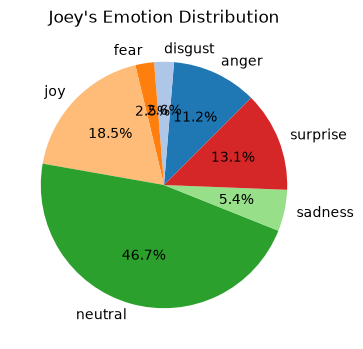

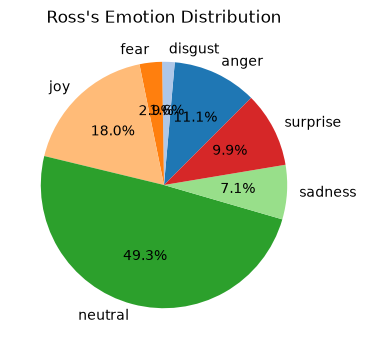

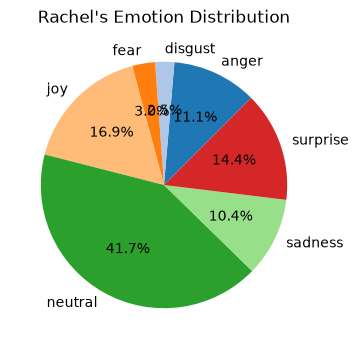

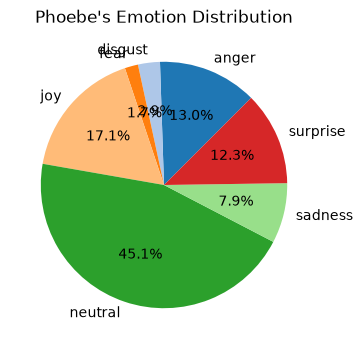

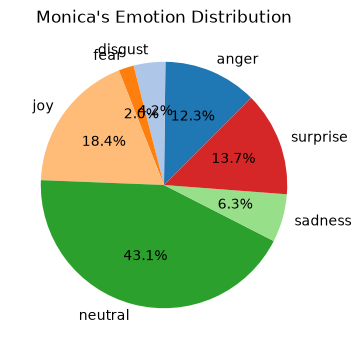

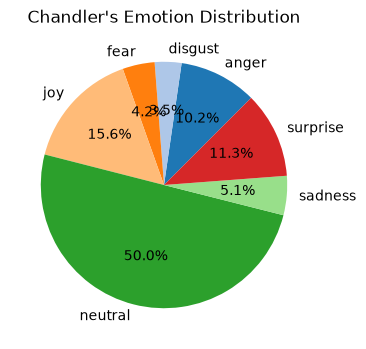

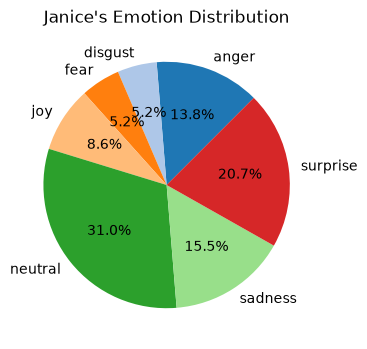

In [17]:
for i in speakers:
    data = map_emotions[i]
    colors = plt.cm.tab20.colors[: len(map_emotions[i])]
    plt.figure(figsize=(4, 4))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=45,
        colors=colors,
    )

    plt.title(f"{i.capitalize()}'s Emotion Distribution")
    plt.show()


In [18]:
print("speaker and their most frequent emotion:")

for speaker in speakers:
    data = map_emotions[speaker].to_dict()
    print(f"{speaker}: ", max(data, key = data.get))

speaker and their most frequent emotion:
Joey:  neutral
Ross:  neutral
Rachel:  neutral
Phoebe:  neutral
Monica:  neutral
Chandler:  neutral
Janice:  neutral


In [19]:
print("sentiment distribution: ")

train_sent = dict(Counter(train['Sentiment']).most_common())
val_sent = dict(Counter(val['Sentiment']).most_common())
test_sent = dict(Counter(test['Sentiment']).most_common())

sent_distb = pd.DataFrame({
    'train': train_sent,
    'val': val_sent,
    'test': test_sent
})

sent_distb

sentiment distribution: 


,train,val,test
neutral,4710,470,1256
negative,2945,406,833
positive,2334,233,521


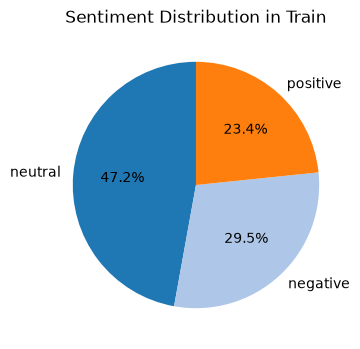

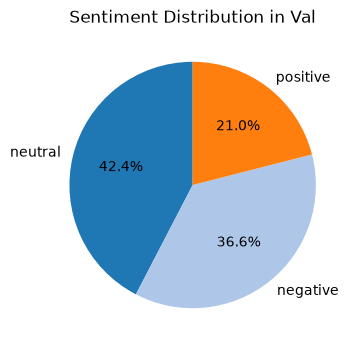

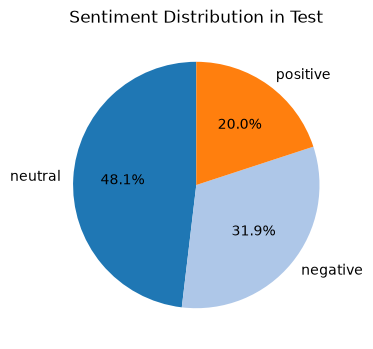

In [20]:
for i in ['train', 'val', 'test']:
    data = sent_distb[i]
    colors = plt.cm.tab20.colors[: len(sent_distb[i])]
    plt.figure(figsize=(4, 4))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
    )

    plt.title(f"Sentiment Distribution in {i.capitalize()}")
    plt.show()


NOTE TO SELF: Add markdowns + analysis

In [21]:
print("sentiment distribution per speaker: ")
speakers = list(train_utt.keys())
sentiments = list(train['Sentiment'].unique())

print("considering speakers: ", speakers)
print("available sentiments: ", sentiments)

train_speakers = train[train['Speaker'].isin(speakers)][['Speaker', 'Sentiment']]
map_sentiments = pd.DataFrame(pd.crosstab(train_speakers['Speaker'], train_speakers['Sentiment']).to_dict(orient = 'index'))

map_sentiments


sentiment distribution per speaker: 
considering speakers:  ['Joey', 'Ross', 'Rachel', 'Phoebe', 'Monica', 'Chandler', 'Janice', 'Carol', 'Emily', 'Tag', 'Mona', 'Doug', 'All', 'Richard', 'Pete', 'Mark', 'Danny', 'Mr. Treeger', 'Joanna', 'Mr. Geller', 'Julie', 'Elizabeth', 'Mrs. Geller', 'Paul', 'Eric', 'Dr. Green', 'Susan', 'Phoebe Sr', 'Woman', 'Earl', 'Barry', 'Frank', 'Chip', 'Gunther', 'Kate', 'Charlie', 'Mr. Tribbiani', 'Joshua', 'Cassie', 'Kristen', 'David', 'The Casting Director', 'Dina', 'Julio', 'Katie', 'Ben', 'Russell', 'Jill', 'Policeman', 'Man', 'Lydia', 'Issac', 'Stanley', 'The Interviewer', 'Mischa', 'Janine', 'Robert', 'Kathy', 'Guy', 'Receptionist', 'The Cooking Teacher', 'Krista', 'Cliff', 'Mr. Heckles', 'Isabella', 'Dr. Baldhara', 'Chloe', 'Mike', 'Dana', 'Joey/Drake', 'Nurse', 'The Director', 'Mr. Franklin', 'Kim', 'Duncan', 'Gary', 'Megan', 'Shelley', 'Ursula', 'Jim', 'The Potential Roommate', 'Terry', 'Larry', "Joey's Hand Twin", 'Fireman No. 3', 'Young Ethan', '

,1st Customer,2nd Customer,3rd Customer,A Female Student,A Student,Airline Employee,Alice,All,Allesandro,Angela,...,Trudie Styler,Ursula,Vince,Voice,Waiter,Wayne,Woman,Woman On Train,Young Ethan,an
negative,0,0,1,0,1,0,0,10,1,0,...,0,1,0,0,0,1,6,0,1,0
neutral,0,0,1,1,0,2,3,11,3,2,...,4,6,0,1,1,0,7,4,3,0
positive,1,1,0,0,0,0,0,12,0,2,...,0,1,1,1,0,0,4,0,2,2


In [22]:
print("top 7 speakers & their sentiment distributions:")

speakers = list(train_utt.keys())[:7]
map_sentiments[speakers]

top 7 speakers & their sentiment distributions:


,Joey,Ross,Rachel,Phoebe,Monica,Chandler,Janice
negative,434,398,475,413,423,383,29
neutral,705,719,598,596,560,642,18
positive,370,342,362,312,316,258,11


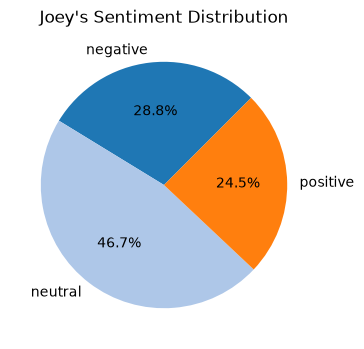

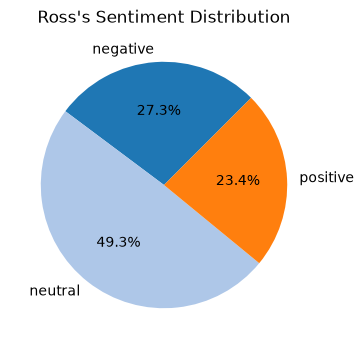

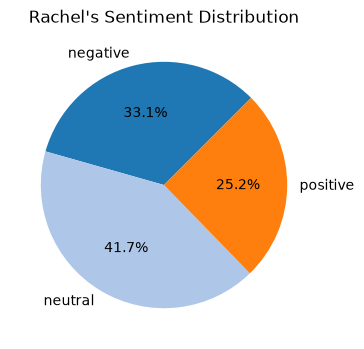

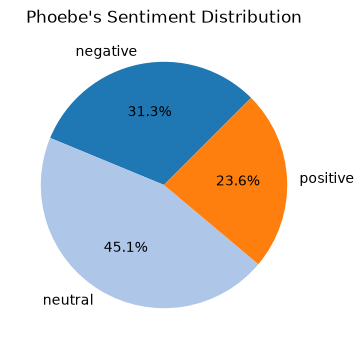

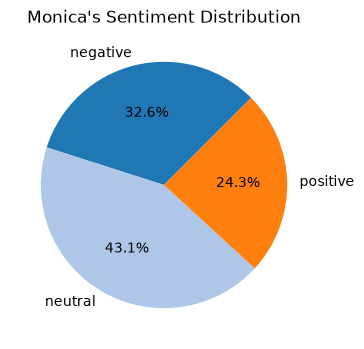

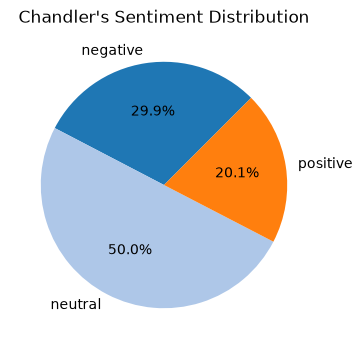

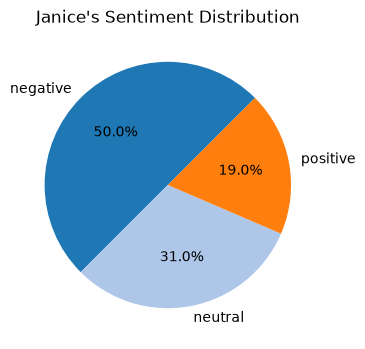

In [23]:
for i in speakers:
    data = map_sentiments[i]
    colors = plt.cm.tab20.colors[: len(map_sentiments[i])]
    plt.figure(figsize=(4, 4))
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        startangle=45,
        colors=colors,
    )

    plt.title(f"{i.capitalize()}'s Sentiment Distribution")
    plt.show()

In [24]:
print("speaker and their most frequent sentiment:")

for speaker in speakers:
    data = map_sentiments[speaker].to_dict()
    print(f"{speaker}: ", max(data, key = data.get))

speaker and their most frequent sentiment:
Joey:  neutral
Ross:  neutral
Rachel:  neutral
Phoebe:  neutral
Monica:  neutral
Chandler:  neutral
Janice:  negative


| Detecting class imbalances through ratios?

In [31]:
train_utt_list = train['Utterance'].tolist()
val_utt_list = val['Utterance'].tolist()
test_utt_list = test['Utterance'].tolist()

In [35]:
max_utt_len = pd.Series({
    'train': np.max([len(i) for i in train_utt_list]),
    'val/dev': np.max([len(i) for i in val_utt_list]),
    'test': np.max([len(i) for i in test_utt_list])
})

print("maximum utterance length:")
max_utt_len

maximum utterance length:


train      327
val/dev    181
test       236
dtype: int64

In [36]:
avg_utt_len = pd.Series({
    'train': round(np.mean([len(i) for i in train_utt_list]), 2),
    'val/dev': round(np.mean([len(i) for i in val_utt_list]), 2),
    'test': round(np.mean([len(i) for i in test_utt_list]), 2)
})

print("average utterance length: ")
avg_utt_len

average utterance length: 


train      40.53
val/dev    40.26
test       41.93
dtype: float64

In [26]:
start_sec = [(i[:8] if len(i) == 12 else i[:7] if len(i) == 11 else i) for i in train['StartTime']]
end_sec = [(i[:8] if len(i) == 12 else i[:7] if len(i) == 11 else i) for i in train['EndTime']]
start_converted, end_converted = [], []

for i in start_sec:
    h, m, s = map(int, i.split(':'))
    start_converted.append(h * 3600 + m * 60 + s)

for i in end_sec:
    h, m, s = map(int, i.split(':'))
    end_converted.append(h * 3600 + m * 60 + s)

total_dur = np.subtract(end_converted, start_converted)

print("average utterance duration (w/o microseconds): ", round(np.mean(total_dur), 2))
print("maximum utterance duration: ", np.max(total_dur))

average utterance duration (w/o microseconds):  3.13
maximum utterance duration:  41
